In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hnn_core import simulate_dipole, jones_2009_model

--No graphics will be displayed.


In [3]:
def syn_conductance_kernel(t_vec, tau1=10., tau2=20.):
    tp = (tau1 * tau2) / (tau2 - tau1) * np.log(tau2 / tau1)
    norm_factor = 1 / (-np.exp(-tp / tau1) + np.exp(-tp / tau2))
    G = norm_factor * (-np.exp(-t_vec / tau1) + np.exp(-t_vec / tau2))
    return G

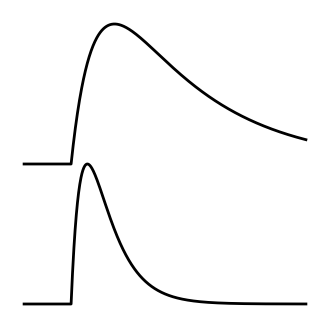

In [26]:
t_vec = np.linspace(0, 200, 1000)
plt.figure(figsize=(4,4))
plt.plot(np.concatenate([np.zeros(200), syn_conductance_kernel(t_vec)]), color='k', linewidth=2)
plt.plot(np.concatenate([np.zeros(200), syn_conductance_kernel(t_vec, tau1=20, tau2=80)]) + 1, color='k', linewidth=2)

plt.axis('off')

plt.savefig('generic_ephys_figures/epsc_time_constants.svg')

In [49]:
net_small = jones_2009_model(mesh_shape=(2,2))
net_small.add_tonic_bias(amplitude={'L5_pyramidal':2., 'L5_basket': 0.8}, t0=20)
net_small.clear_connectivity()

simulate_dipole(net_small, tstop=310, record_vsec='all', record_isec='all')

Joblib will run 1 trial(s) in parallel by distributing trials over 1 jobs.
Building the NEURON model
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Trial 1: 250.0 ms...
Trial 1: 260.0 ms...
Trial 1: 270.0 ms...
Trial 1: 280.0 ms...
Trial 1: 290.0 ms...
Trial 1: 300.0 ms...


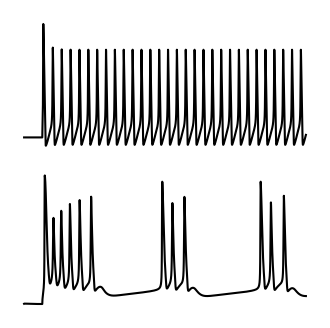

In [51]:
soma_v1 = np.array(net_small.cell_response.vsec[0][list(net_small.gid_ranges['L5_pyramidal'])[0]]['soma'])

soma_v2 = np.array(net_small.cell_response.vsec[0][list(net_small.gid_ranges['L5_basket'])[0]]['soma'])


plt.figure(figsize=(4,4))
plt.plot(net_small.cell_response.times, soma_v1, color='k', linewidth=1.5)

plt.plot(net_small.cell_response.times, soma_v2 + 150, color='k', linewidth=1.5)

plt.axis('off')
# plt.xlim(10, 70)
plt.savefig('generic_ephys_figures/membrane_potential_firing_types.svg')

In [2]:
net_small = jones_2009_model(mesh_shape=(2,2))
net_small.add_tonic_bias(cell_type='L5_pyramidal', amplitude=0.8, t0=20)

simulate_dipole(net_small, tstop=100, record_vsec='all', record_isec='all')

Joblib will run 1 trial(s) in parallel by distributing trials over 1 jobs.
Loading custom mechanism files from /oscar/home/ntolley/Jones_Lab/hnn_schizophrenia_drug/externals/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Building the NEURON model
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...


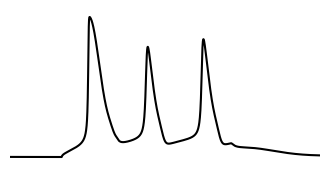

In [3]:
soma_v = net_small.cell_response.vsec[0][list(net_small.gid_ranges['L5_pyramidal'])[0]]['soma']

plt.figure(figsize=(4,2))
plt.plot(net_small.cell_response.times, soma_v, color='k', linewidth=1.5)
plt.axis('off')
plt.xlim(10, 70)
plt.savefig('generic_ephys_figures/soma_voltage.svg')

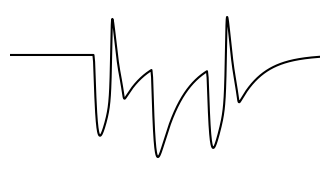

In [4]:
synapse_i = net_small.cell_response.isec[0][7]['soma']['soma_ampa']

plt.figure(figsize=(4,2))
plt.plot(net_small.cell_response.times, synapse_i, color='k', linewidth=1.5)
plt.axis('off')
plt.xlim(10, 70)
plt.savefig('generic_ephys_figures/synaptic_current.svg')

In [6]:
net = jones_2009_model()

weights_ampa = {'L2_pyramidal': 0.0008, 'L5_pyramidal': 0.0075}
synaptic_delays = {'L2_pyramidal': 0.1, 'L5_pyramidal': 1.0}
rate_constant = {'L2_pyramidal': 140.0, 'L5_pyramidal': 40.0}
net.add_poisson_drive(
    'poisson', rate_constant=rate_constant, weights_ampa=weights_ampa,
    location='proximal', synaptic_delays=synaptic_delays,
    event_seed=1349)

dpl = simulate_dipole(net, tstop=500, dt=0.5, n_trials=4)


Joblib will run 4 trial(s) in parallel by distributing trials over 1 jobs.
Building the NEURON model
[Done]
Trial 1: 0.5 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Trial 1: 250.0 ms...
Trial 1: 260.0 ms...
Trial 1: 270.0 ms...
Trial 1: 280.0 ms...
Trial 1: 290.0 ms...
Trial 1: 300.0 ms...
Trial 1: 310.0 ms...
Trial 1: 320.0 ms...
Trial 1: 330.0 ms...
Trial 1: 340.0 ms...
Trial 1: 350.0 ms...
Trial 1: 360.0 ms...
Trial 1: 370.0 ms...
Trial 1: 380.0 ms...
Trial 1: 390.0 ms...
Trial 1: 400.0 ms...
Trial 1: 410.0 ms...
Trial 1: 420.0 ms...


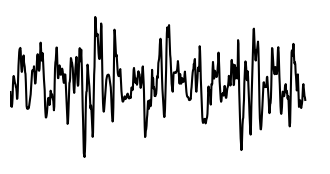

In [7]:
dpl_data = dpl[0].data['agg']

times_mask = net.cell_response.times > 100
plt.figure(figsize=(4,2))
plt.plot(net.cell_response.times[times_mask], dpl_data[times_mask], color='k', linewidth=1.5)
plt.axis('off')
plt.xlim(100, None)
plt.savefig('generic_ephys_figures/eeg_dipole.svg')